This notebook is based on the paper by Catherine F. Higham and Desmond J. Higham:

**Deep Learning: An Introduction for Applied Mathematicians.**

*SIAM Review*, Vol. 61, No. 4, pages 860-891, 2019.

The Flux package will be applied to solve the example of the paper.

In [1]:
using Plots

In [2]:
using Flux

## 1. sigmoids

The sigmoid function

$$
    y = \frac{1}{1 + e^{-x}}
$$

can be viewed as a smoothed step function.

In [3]:
sigmoid(3)

0.9525741268224334

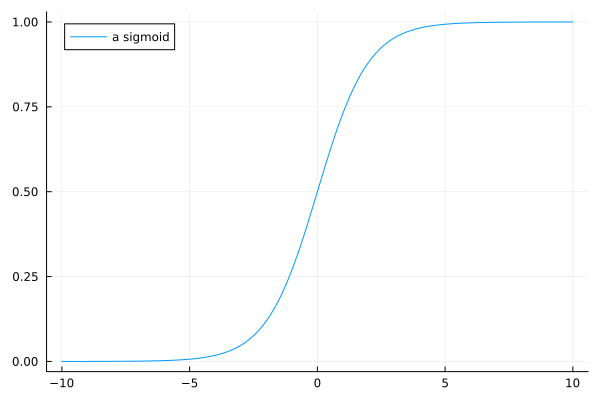

In [4]:
plot(-10:0.01:10, sigmoid, label="a sigmoid", legend=:topleft)

Sigmoids are defined explicitly by the ``activate`` function below, which takes on input, in addition to ``x``, also the weights matrix ``W`` and the bias vector ``b``.

In [5]:
"""
    function activate(x,W,b)

Evaluates sigmoid function.

    x is the input vector
    y is the output vector

    W contains the weights, b contains the shifts

    If x has s components and y has r components, then
    W is an r by s matrix and b is a vector of length s

    The ith component of y is activate((Wx+b)_i)
    where activate(z) = 1/(1+exp(-z)).

    C F Higham and D J Higham, August 2017
"""
function activate(x,W,b)
    dim = size(W,1)
    y = zeros(dim)
    argexp = -(W*x + b)
    for i=1:dim # y = 1.0 /(1.0 + exp(-(W*x +b)))
        y[i] = 1.0/(1.0 + exp(argexp[i]))
    end
    return y
end

activate

In [6]:
W = zeros(1,1)
W[1,1] = 3.0
y = activate([2.0], W, [-15.0])

1-element Vector{Float64}:
 0.00012339457598623172

In [7]:
f(x) = sigmoid(3*(x-5))
f(2)

0.00012339457598623172

## 2. An Artificial Neural Network

Let us make a network with three layers.

In [8]:
"""
    function F(x, W2, W3, W3, b2, b3, b4)

returns the output of network 
with weights in the matrices W2, W3, W4, and
with bias vectors b2, b3, b4.
"""
function F(x, W2, W3, W4, b2, b3, b4)
    a2 = activate(x, W2, b2)
    a3 = activate(a2, W3, b3)
    a4 = activate(a3, W4, b4)
    return a4
end

F

The number of neurons in each layer are determined by the dimensions of the weights and the bias vectors.
Let us generate weights and vectors of random numbers.

In [9]:
W2 = 0.5*randn(2,2); println("W2 = \n", W2)
W3 = 0.5*randn(3,2); println("W3 = \n", W3)
W4 = 0.5*randn(2,3); println("W4 = \n", W4)
b2 = 0.5*randn(2); println("b2 = \n", b2)
b3 = 0.5*randn(3); println("b3 = \n", b3)
b4 = 0.5*randn(2); println("b4 = \n", b4)

W2 = 
[-0.34949583968349984 0.035300433934996295; -0.061737995978297044 -0.09393250101468284]
W3 = 
[-0.8783953633750915 -0.6109168441556514; 0.36358412998898 -0.43710139271009457; -0.5664975463398928 -0.5965636471010113]
W4 = 
[0.1312311837879594 0.5137244307629355 -0.558228705447121; 0.2598305533581295 -0.20773581084002427 0.5818502112842021]
b2 = 
[-0.8062655748416143, 0.6668701422815569]
b3 = 
[-0.0056136517249980415, 0.3045623660220407, 0.08307838962184773]
b4 = 
[-0.11846499436493164, 1.3711435647670798]


In [10]:
F([1.0; 1.0], W2, W3, W4, b2, b3, b4)

2-element Vector{Float64}:
 0.4950389564597887
 0.8295320739662246

Now we will use Flux to define the same network as ``F``.

In [11]:
L2 = Dense(W2, b2, sigmoid)

Dense(2 => 2, σ)    # 6 parameters

In [12]:
dump(L2)

Dense{typeof(σ), Matrix{Float64}, Vector{Float64}}
  weight: Array{Float64}((2, 2)) [-0.34949583968349984 0.035300433934996295; -0.061737995978297044 -0.09393250101468284]
  bias: Array{Float64}((2,)) [-0.8062655748416143, 0.6668701422815569]
  σ: σ (function of type typeof(σ))


In [13]:
L3 = Dense(W3, b3, sigmoid)

Dense(2 => 3, σ)    # 9 parameters

In [14]:
dump(L3)

Dense{typeof(σ), Matrix{Float64}, Vector{Float64}}
  weight: Array{Float64}((3, 2)) [-0.8783953633750915 -0.6109168441556514; 0.36358412998898 -0.43710139271009457; -0.5664975463398928 -0.5965636471010113]
  bias: Array{Float64}((3,)) [-0.0056136517249980415, 0.3045623660220407, 0.08307838962184773]
  σ: σ (function of type typeof(σ))


In [15]:
L4 = Dense(W4, b4, sigmoid)

Dense(3 => 2, σ)    # 8 parameters

In [16]:
M = Chain(L2, L3, L4)

Chain(
  Dense(2 => 2, σ),                     # 6 parameters
  Dense(2 => 3, σ),                     # 9 parameters
  Dense(3 => 2, σ),                     # 8 parameters
)                   # Total: 6 arrays, 23 parameters, 496 bytes.

Let us do a random point test.  If ``F`` and ``M`` gives the same value at a random point, then with probability one, we can be sure they are the same function.

In [17]:
xpt = [randn(1); randn(1)]

2-element Vector{Float64}:
 -0.175735582795903
  0.0855720189618344

In [18]:
Mxpt = M(xpt)

2-element Vector{Float64}:
 0.4969149041592923
 0.8274217474545119

In [19]:
Fxpt = F(xpt, W2, W3, W4, b2, b3, b4)

2-element Vector{Float64}:
 0.4969149041592923
 0.8274217474545119

In [20]:
Mxpt - Fxpt

2-element Vector{Float64}:
 0.0
 0.0

## 3. Training the Network

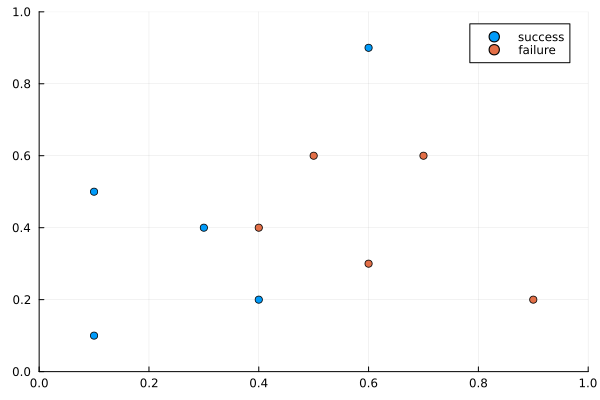

In [21]:
x1 = [0.1,0.3,0.1,0.6,0.4,0.6,0.5,0.9,0.4,0.7]
x2 = [0.1,0.4,0.5,0.9,0.2,0.3,0.6,0.2,0.4,0.6]
scatter(x1[1:5],x2[1:5], label="success", xlims=[0,1], ylims=[0,1])
scatter!(x1[6:10],x2[6:10], label="failure")

The labels are defined by ``ylabels``.

In [22]:
ylabels = [ones(1,5) zeros(1,5); zeros(1,5) ones(1,5)]

2×10 Matrix{Float64}:
 1.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0

In the Forward and Back propagate
a training point is picked at random.

In [23]:
eta = 0.05
Niter = 1000000
for counter = 1:Niter
    k = rand((1:10), 1)[1]
    x = [x1[k], x2[k]]
    # Forward pass
    a2 = activate(x,W2,b2)
    a3 = activate(a2,W3,b3)
    a4 = activate(a3,W4,b4)
    # Backward pass
    delta4 = a4.*(ones(length(a4))-a4).*(a4-ylabels[:,k])
    delta3 = a3.*(ones(length(a3))-a3).*(W4'*delta4)
    delta2 = a2.*(ones(length(a2))-a2).*(W3'*delta3)
    # Gradient step
    W2 = W2 - eta*delta2*x'
    W3 = W3 - eta*delta3*a2'
    W4 = W4 - eta*delta4*a3'
    b2 = b2 - eta*delta2
    b3 = b3 - eta*delta3
    b4 = b4 - eta*delta4
end

In [24]:
Z = [[x1[k], x2[k]] for k=1:10]

10-element Vector{Vector{Float64}}:
 [0.1, 0.1]
 [0.3, 0.4]
 [0.1, 0.5]
 [0.6, 0.9]
 [0.4, 0.2]
 [0.6, 0.3]
 [0.5, 0.6]
 [0.9, 0.2]
 [0.4, 0.4]
 [0.7, 0.6]

In [25]:
Y = [F(z, W2, W3, W4, b2, b3, b4) for z in Z]

10-element Vector{Vector{Float64}}:
 [0.9998988622513868, 0.00010104092559339211]
 [0.9899660909194247, 0.010017205861357664]
 [0.9999175170203776, 8.23348138803265e-5]
 [0.9946976646303691, 0.005252843141435304]
 [0.9930393986251943, 0.006994760513069382]
 [0.0001807704136829395, 0.9998196006411346]
 [0.0032417314434174276, 0.9967493982203736]
 [5.7218300279589774e-5, 0.9999428743812182]
 [0.012462807513382163, 0.9875549308871817]
 [5.661924815658111e-5, 0.9999434517294743]

In [26]:
success = []
failure = []
for i=0:0.01:1
    for j=0:0.01:1
        y = F([i,j], W2, W3, W4, b2, b3, b4)
        if y[1] > y[2]
            push!(success, [i, j])
        else
            push!(failure, [i, j])
        end
    end
end

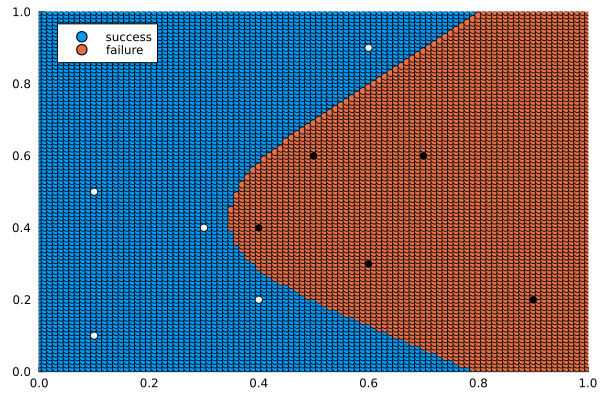

In [27]:
x1f = [z[1] for z in failure]
x2f = [z[2] for z in failure]
x1s = [z[1] for z in success]
x2s = [z[2] for z in success]
scatter(x1s, x2s, label="success", xlims=[0,1], ylims=[0,1], legend=:topleft)
scatter!(x1f, x2f, label="failure")
scatter!(x1[1:5],x2[1:5], label="", xlims=[0,1], ylims=[0,1], color="white")
scatter!(x1[6:10],x2[6:10], label="", color="black")

In [28]:
# savefig("figevaluatedresults1.png")

Let us now train with Flux.

In [29]:
M(xpt)

2-element Vector{Float64}:
 0.4969149041592923
 0.8274217474545119

In [30]:
F(xpt, W2, W3, W4, b2, b3, b4)

2-element Vector{Float64}:
 0.9999305876138446
 6.927020643926361e-5

The above computations show that the random weight and bias vectors used to initialize the model with did not change, even though the matrices W2, W3, W4, and the vectors b2, b3, b4, used to initialize the model did change.

## 3.1 the loss function

To define the loss function, we compare the difference between the values of the model at the ten points with coordinates in ``x1`` and ``x2`` with the labels provided in ``y``.

In [31]:
"""
    function loss(m, x, y)

defines the loss of the model m at the training point (x, y).
"""
function loss(m, x, y)
    result = 0.0
    for i=1:10
        point = [x1[i]; x2[i]]
        yy = m(point)
        result = result + 0.5*((yy[1] - ylabels[1,i])^2 + (yy[2] - ylabels[2,i])^2)
    end
    return result/10.0
end

loss

In [32]:
loss(M, xpt, xpt)

0.3037163777059063

### 3.1 define the training data

In [33]:
N = 1_000_000
xtrain = [randn(2) for _ in 1:N];
ytrain = [randn(2) for _ in 1:N];

In [34]:
train_data = zip(xtrain, ytrain);

In [35]:
opt = Descent(0.01)

Descent(0.01)

In [36]:
# ps = Flux.params(M) # is deprecated
ps = Flux.trainable(M)

(layers = (Dense(2 => 2, σ), Dense(2 => 3, σ), Dense(3 => 2, σ)),)

In [37]:
Flux.train!(loss, M, train_data, opt)

In [38]:
[M(z) for z in Z]

10-element Vector{Vector{Float64}}:
 [0.9996692520834741, 0.0003299712414006603]
 [0.9630975406941047, 0.03684258132881149]
 [0.9997422123501871, 0.0002567921728714734]
 [0.9824308303011804, 0.01739771850328602]
 [0.9752707323527204, 0.024834047472037688]
 [0.000927438144467246, 0.9990759816727646]
 [0.011152650309211731, 0.9888225022200291]
 [0.0002360629176423055, 0.9997648038300239]
 [0.0450310830458518, 0.9550352384063621]
 [0.0002528167778015031, 0.9997479152824524]

In [39]:
success = []
failure = []
for i=0:0.01:1
    for j=0:0.01:1
        y = M([i,j])
        if y[1] > y[2]
            push!(success, [i, j])
        else
            push!(failure, [i, j])
        end
    end
end

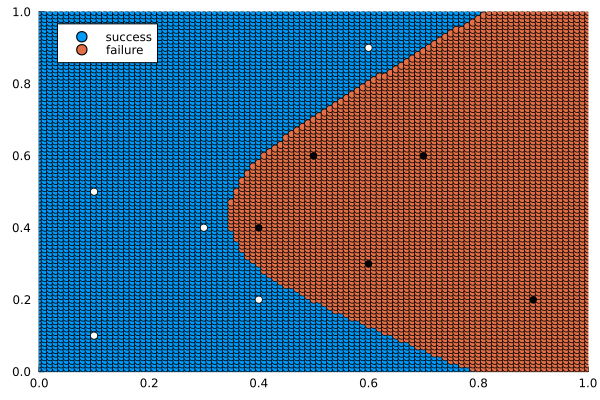

In [40]:
x1f = [z[1] for z in failure]
x2f = [z[2] for z in failure]
x1s = [z[1] for z in success]
x2s = [z[2] for z in success]
scatter(x1s, x2s, label="success", xlims=[0,1], ylims=[0,1], legend=:topleft)
scatter!(x1f, x2f, label="failure")
scatter!(x1[1:5],x2[1:5], label="", xlims=[0,1], ylims=[0,1], color="white")
scatter!(x1[6:10],x2[6:10], label="", color="black")

In [41]:
# savefig("figevaluatedresults2.png")

In [42]:
Flux.params(M)

┌ Warning: `Flux.params(m...)` is deprecated. Use `Flux.trainable(model)` for parameter collection,
│ and the explicit `gradient(m -> loss(m, x, y), model)` for gradient computation.
└ @ Flux C:\Users\jan\.julia\packages\Flux\DZYiO\src\deprecations.jl:93


Params([[-7.279077128045507 7.912245361480192; -5.469875314887702 -8.592718071068807], [-1.7428795968247042, 4.53156475395929], [-4.1926375778595455 -4.500499381547834; 6.3456553814278935 6.272138828265693; -5.7327829061736395 -6.1034199107797615], [2.186964224977558, -3.358732442475399, 3.1431005743301674], [-4.519422111498271 7.515540029469907 -6.66400327731244; 4.592081815244246 -7.772574232963002 6.345883681611244], [1.1289948779514136, -0.8766521576503359]])

In [43]:
W2 = 0.5*randn(2,2); println("W2 = \n", W2)
W3 = 0.5*randn(3,2); println("W3 = \n", W3)
W4 = 0.5*randn(2,3); println("W4 = \n", W4)
b2 = 0.5*randn(2); println("b2 = \n", b2)
b3 = 0.5*randn(3); println("b3 = \n", b3)
b4 = 0.5*randn(2); println("b4 = \n", b4)

W2 = 
[0.38343359989887876 0.40763959098926705; 0.19508192697189197 0.5118175168735621]
W3 = 
[-0.1183554343839735 -0.15004459861331274; 0.8716558928729016 0.4068620845495162; -0.2648490847501101 -0.04881662121639218]
W4 = 
[0.4908823576298585 -0.704039506002869 0.1345147591314598; -0.7841435918309797 -0.19345897898716288 0.4640155054557537]
b2 = 
[-1.0204213694169146, 0.8524399625008953]
b3 = 
[0.5483738502722572, 0.27087183649801533, 0.2729525080342052]
b4 = 
[1.0187254983983882, -0.5722192250066839]
